# SF Housing Intelligence Platform

## Notebook 03 - Exploratory Data Analysis

### Objective

Explore the cleaned San Francisco Housing Inventory dataset to identify housing patterns, affordability trends, neighborhood differences, and factors influencing rental prices. These insights will guide dashboard development and future machine learning models.

In [9]:
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt


In [4]:
df = pd.read_csv(
    "../data/processed/housing_cleaned.csv"
)

In [5]:
df.shape

(546179, 36)

In [6]:
df["analysis_neighborhood"].nunique()

41

In [7]:
housing = (
    df.groupby("analysis_neighborhood")
      .size()
      .sort_values(ascending=False)
)

housing

analysis_neighborhood
Nob Hill                          50452
Tenderloin                        42278
Mission                           40564
Marina                            31535
Pacific Heights                   31291
Financial District/South Beach    24636
Russian Hill                      23486
South of Market                   22507
Western Addition                  22436
Hayes Valley                      21768
Outer Richmond                    21035
Lakeshore                         21021
Castro/Upper Market               18097
Chinatown                         17594
Inner Sunset                      15622
Sunset/Parkside                   15095
Haight Ashbury                    14500
Mission Bay                       13802
Inner Richmond                    13346
North Beach                       12487
Noe Valley                        10789
Lone Mountain/USF                  9267
Potrero Hill                       8663
Presidio Heights                   7509
Twin Peaks        

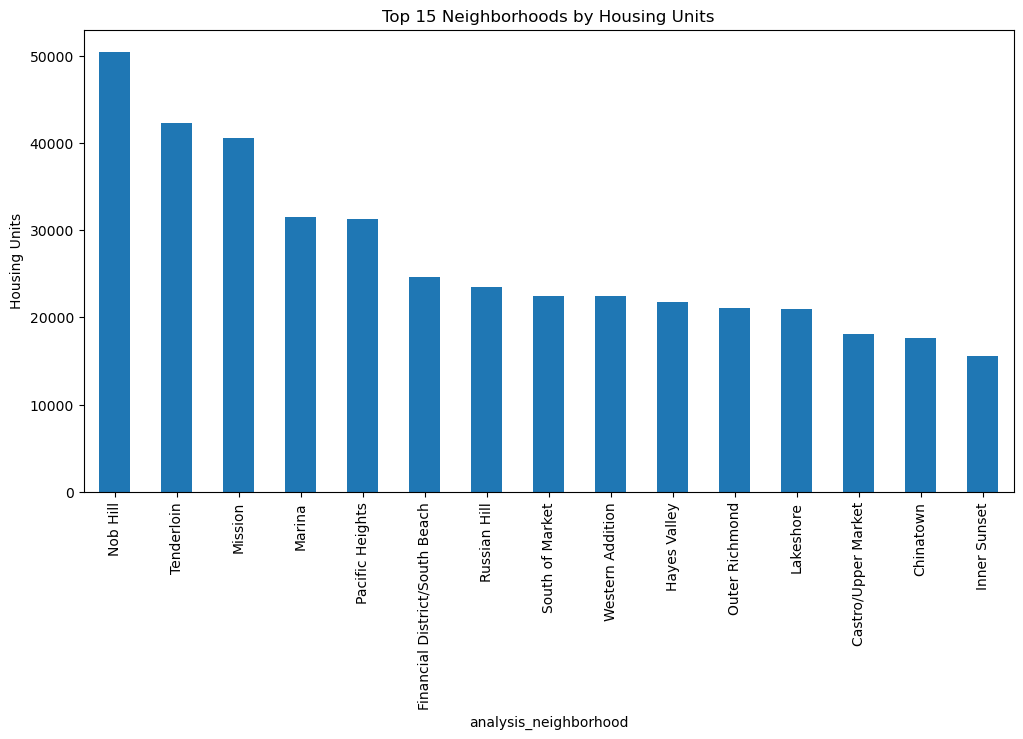

In [10]:
housing.head(15).plot.bar(figsize=(12,6))

plt.title("Top 15 Neighborhoods by Housing Units")
plt.ylabel("Housing Units")
plt.show()

In [11]:
rent = (
    df.groupby("analysis_neighborhood")
      ["monthly_rent_mid"]
      .median()
      .sort_values(ascending=False)
)

rent

analysis_neighborhood
Presidio                          6875.5
Mission Bay                       3625.5
Financial District/South Beach    3125.5
Glen Park                         3125.5
Potrero Hill                      3125.5
Bayview Hunters Point             2875.5
Marina                            2875.5
West of Twin Peaks                2875.5
Pacific Heights                   2875.5
Oceanview/Merced/Ingleside        2875.5
Visitacion Valley                 2625.5
Seacliff                          2625.5
Russian Hill                      2625.5
Presidio Heights                  2625.5
Bernal Heights                    2625.5
Noe Valley                        2625.5
Lone Mountain/USF                 2625.5
Castro/Upper Market               2625.5
Lakeshore                         2625.5
Haight Ashbury                    2625.5
Portola                           2375.5
Twin Peaks                        2375.5
Sunset/Parkside                   2375.5
South of Market                   2

Text(0.5, 1.0, 'Median Monthly Rent by Neighborhood')

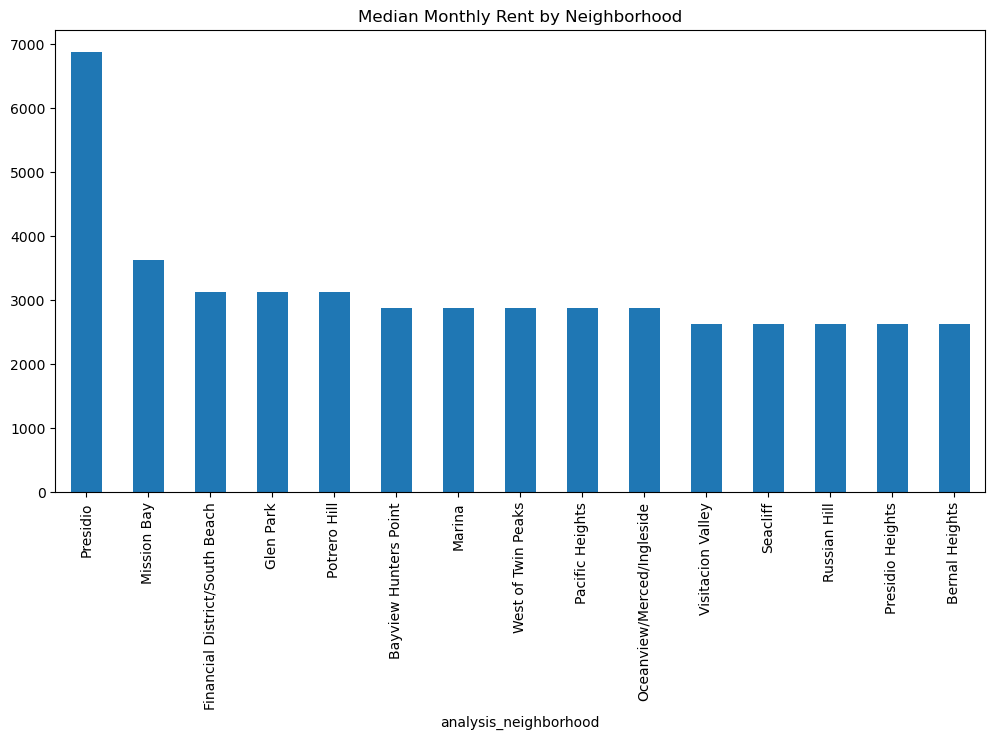

In [12]:
rent.head(15).plot.bar(figsize=(12,6))

plt.title("Median Monthly Rent by Neighborhood")

In [13]:
rent.tail(15)

analysis_neighborhood
Inner Sunset        2375.5
Outer Richmond      2375.5
Japantown           2375.5
Lincoln Park        2375.5
Western Addition    2375.5
Mission             2125.5
Outer Mission       2125.5
Golden Gate Park    2125.5
Excelsior           2125.5
North Beach         2125.5
Treasure Island     1875.5
Nob Hill            1875.5
Tenderloin          1625.5
Chinatown            875.5
McLaren Park           NaN
Name: monthly_rent_mid, dtype: float64

Text(0, 0.5, 'Monthly Rent')

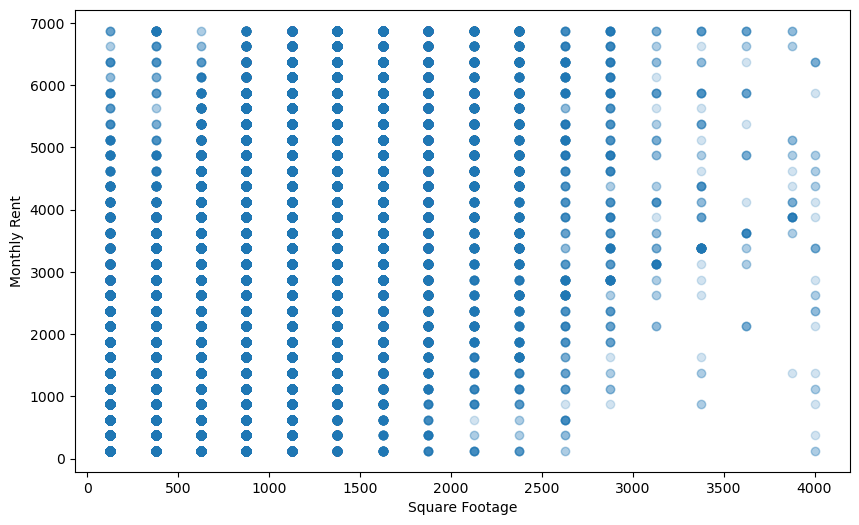

In [14]:
plt.figure(figsize=(10,6))

plt.scatter(
    df["square_footage_mid"],
    df["monthly_rent_mid"],
    alpha=0.2
)

plt.xlabel("Square Footage")

plt.ylabel("Monthly Rent")

Text(0.5, 1.0, 'Distribution of Monthly Rent')

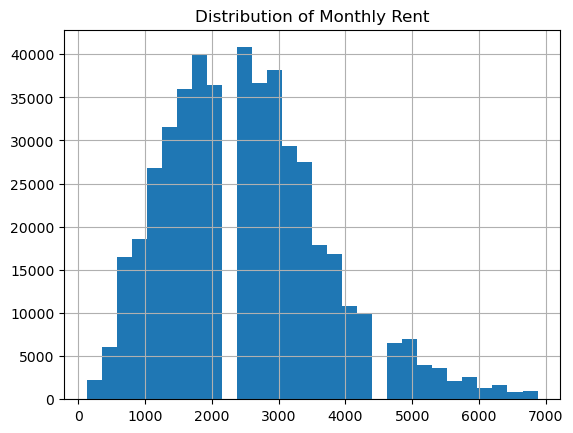

In [15]:
df["monthly_rent_mid"].hist(
    bins=30
)

plt.title("Distribution of Monthly Rent")

<Axes: xlabel='bedroom_num'>

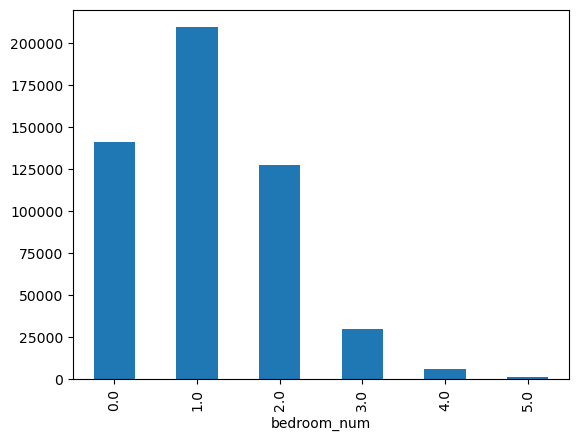

In [16]:
df["bedroom_num"].value_counts().sort_index().plot.bar()

<Axes: xlabel='bathroom_num'>

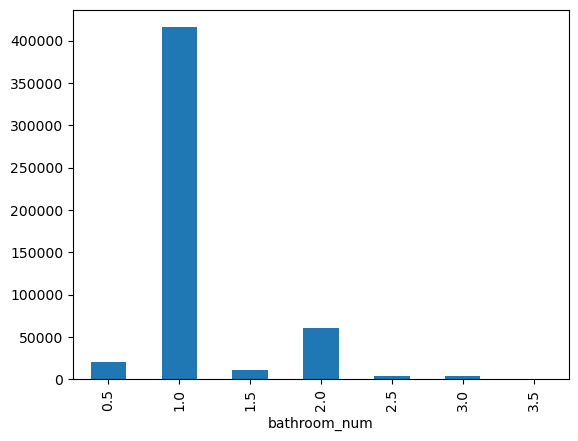

In [17]:
df["bathroom_num"].value_counts().sort_index().plot.bar()

In [18]:
CURRENT_YEAR = 2026

df["property_age"] = (
    CURRENT_YEAR
    - df["year_property_built"]
)

<Axes: >

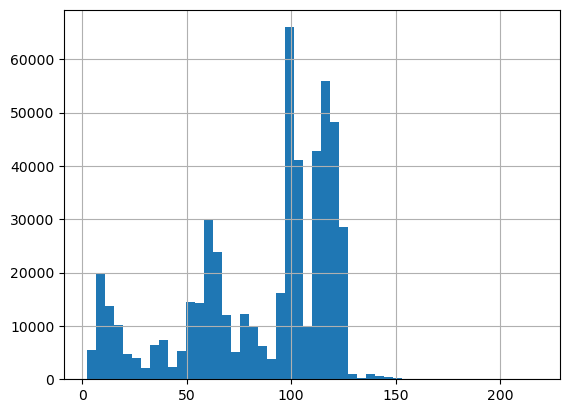

In [21]:
df["property_age"].hist(
    bins=50
)

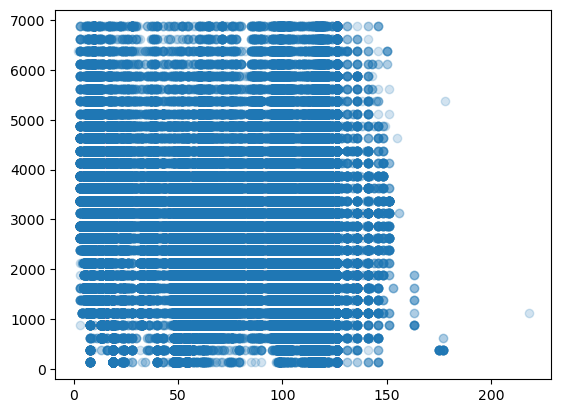

In [23]:
plt.scatter(
    df["property_age"],
    df["monthly_rent_mid"],
    alpha=0.2
)

<Axes: xlabel='occupancy_type'>

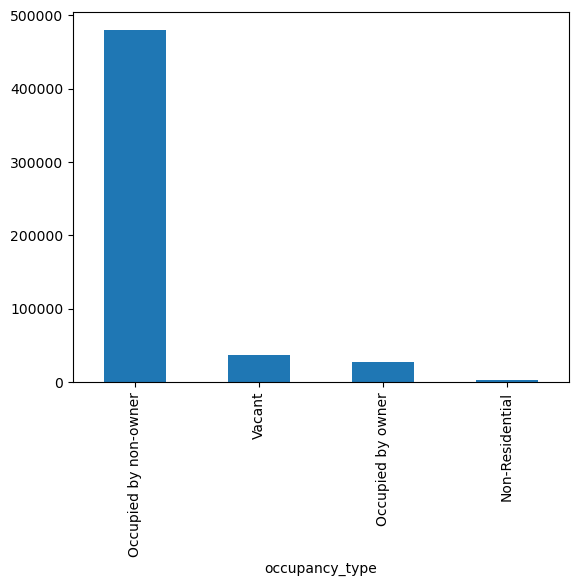

In [24]:
df["occupancy_type"].value_counts().plot.bar()

<Axes: xlabel='submission_year'>

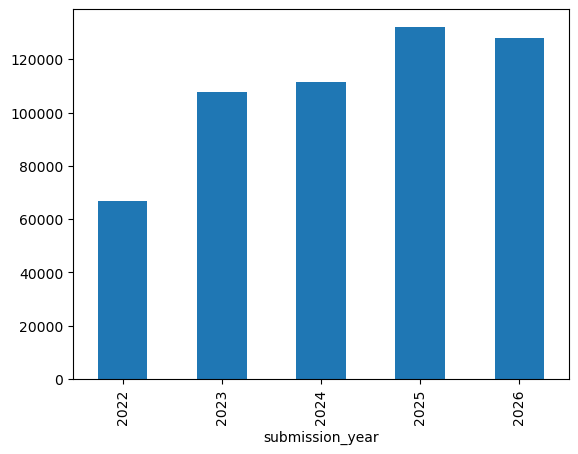

In [25]:
df["submission_year"].value_counts().sort_index().plot.bar()

In [26]:
neighborhood_summary = (
    df.groupby("analysis_neighborhood")
      .agg({
          "monthly_rent_mid":"median",
          "square_footage_mid":"median",
          "bedroom_num":"median"
      })
)

In [27]:
neighborhood_summary.to_csv(
    "../data/processed/neighborhood_summary.csv"
)

KeyError: 'neighborhood'